In [37]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Lasso ,LinearRegression
from sklearn.model_selection import train_test_split

In [2]:
df=pd.read_csv('emp.csv')
df.head()

,EmpID,Experience,Age,Salary,DepartmentSize,ProjectsHandled,ClientRating,RandomNoise1,RandomNoise2,PerformanceScore
0,1,2,24,25000,10,3,4.2,12.5,-3.4,52
1,2,5,29,42000,15,6,4.5,-8.2,5.1,78
2,3,7,32,52000,20,8,4.8,3.2,-6.5,88
3,4,1,23,22000,8,2,3.9,15.6,2.3,45
4,5,10,38,68000,25,12,4.9,-10.5,-4.2,95


In [41]:
x=df.drop(['Salary'],axis=1)
y = df['Salary']

In [67]:
#split into train and test
X_train, X_test, y_train, y_test = train_test_split(x,y,test_size=0.3, random_state=10)
X_train


,EmpID,Experience,Age,DepartmentSize,ProjectsHandled,ClientRating,RandomNoise1,RandomNoise2,PerformanceScore
13,14,7,33,21,8,4.7,2.6,-3.7,85
2,3,7,32,20,8,4.8,3.2,-6.5,88
14,15,3,26,13,4,4.2,-9.4,2.8,62
8,9,4,27,14,5,4.3,-6.7,1.2,70
17,18,4,27,15,5,4.3,8.9,-2.5,72
16,17,6,31,19,7,4.6,-4.2,4.7,83
19,20,1,22,9,2,3.8,6.2,-4.8,43
12,13,5,28,16,6,4.4,-1.5,3.2,76
11,12,9,36,24,10,4.8,7.8,-5.6,92
1,2,5,29,15,6,4.5,-8.2,5.1,78


In [43]:
LR=LinearRegression()
LR.fit(X_train,y_train)
LR.score(X_train,y_train)*100
LR.coef_

array([   47.95529428, -5904.81832476,  1133.76254602,  1181.0508784 ,
        5079.39499647, -6200.64712629,   160.85594272,    20.87390153,
         434.81361034])

In [75]:
LS=Lasso(alpha=10)
LS.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.953e+05, tolerance: 3.881e+05
  model = cd_fast.enet_coordinate_descent(


Lasso(alpha=10)

In [76]:
LS.score(X_train,y_train)*100

99.85297033400208

In [77]:
print('Lasso regression codefficent',LS.coef_)
print('Linear regression codefficent',LR.coef_)


Lasso regression codefficent [  36.45777509 2157.18225307 1322.21858092  178.99740926    8.26014642
    0.          -12.38138163   -2.18348923   85.32617751]
Linear regression codefficent [   47.95529428 -5904.81832476  1133.76254602  1181.0508784
  5079.39499647 -6200.64712629   160.85594272    20.87390153
   434.81361034]


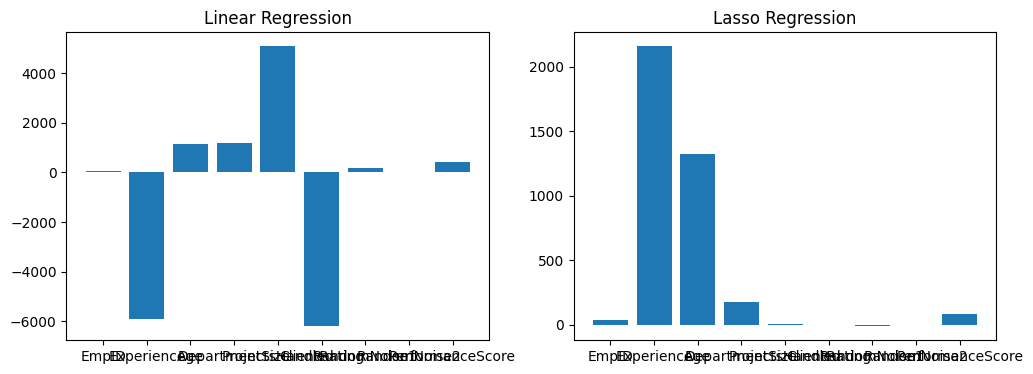

In [78]:
import matplotlib.pyplot as plt
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.bar(x.columns,LR.coef_)
plt.title('Linear Regression')
plt.subplot(1,2,2)
plt.bar(x.columns,LS.coef_)
plt.title('Lasso Regression')
plt.show()

#Ridge regularization


In [72]:
from sklearn.linear_model import Ridge

In [79]:
rig=Ridge(alpha=10)
rig.fit(X_train,y_train)

Ridge(alpha=10)

In [74]:
rig.coef_

array([ -0.96000753, 558.25180894, 922.22490336, 775.54025003,
       719.36948014,  19.42475677,  -1.00417721, -27.19475562,
       161.59247173])

<function matplotlib.pyplot.show(close=None, block=None)>

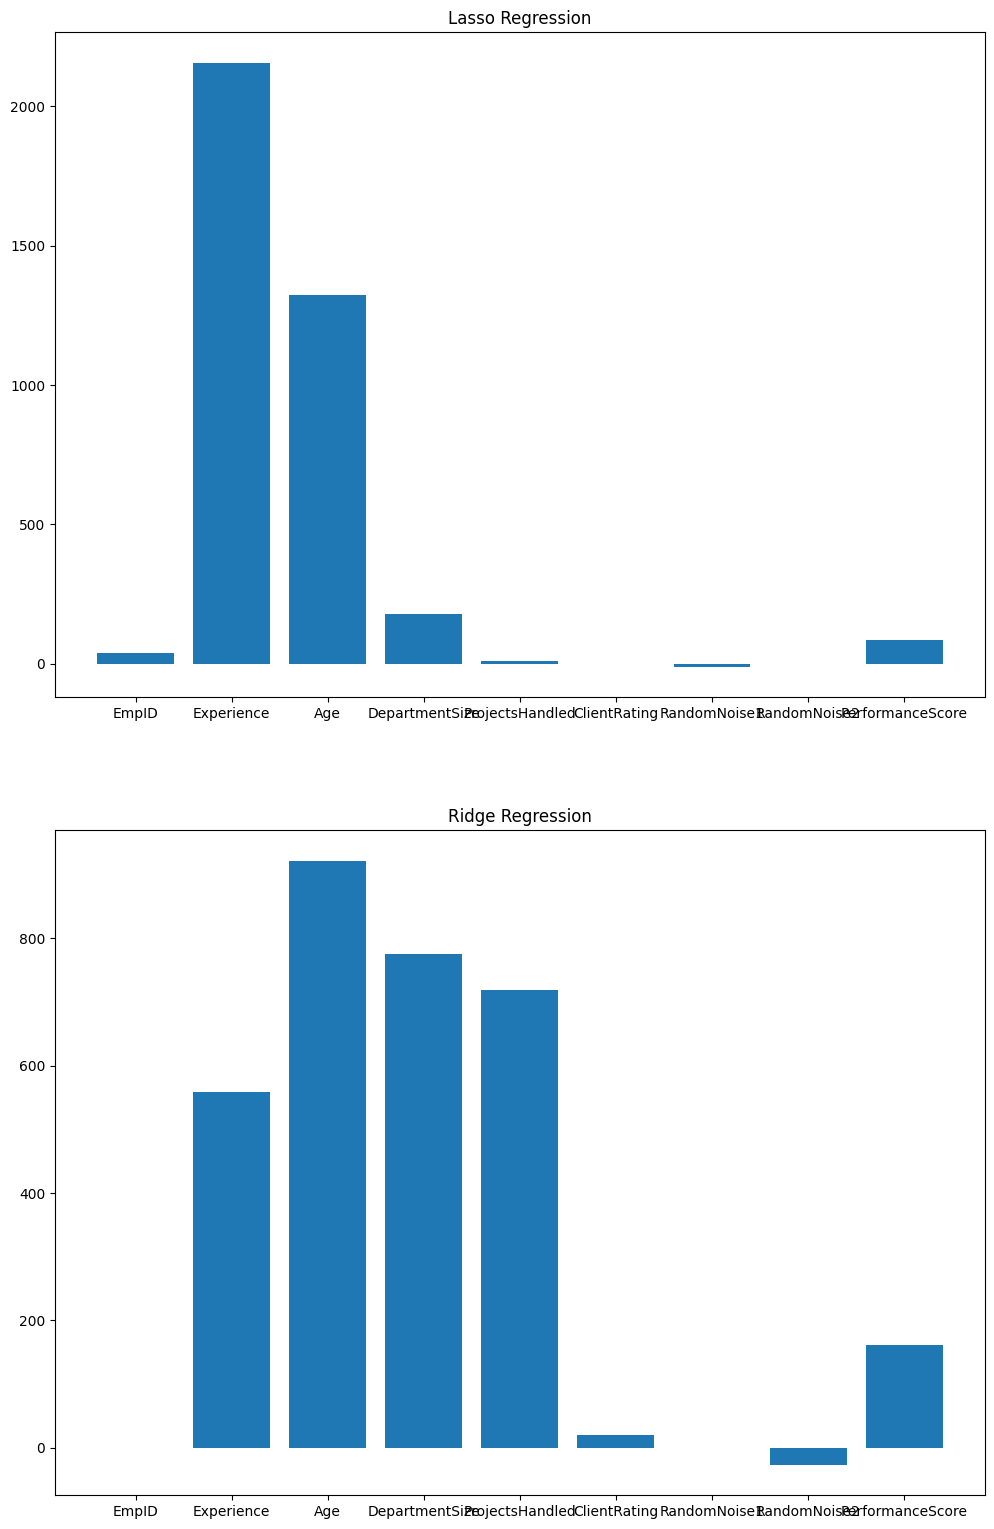

In [84]:
plt.figure(figsize=(12,19))
plt.subplot(2,1,1)
plt.bar(x.columns,LS.coef_)
plt.title('Lasso Regression')
plt.subplot(2,1,2)
plt.bar(x.columns,rig.coef_)
plt.title('Ridge Regression')
plt.show
